# 資料分析

1. 資料讀取
- 載入 `data/df_clean.csv`
- 確認欄位與資料筆數

2. 探索性分析（EDA）

    2.1 基本統計
    - 計算 `Duration (minutes)` 的 mean、median、std、min、max
    - 輸出統計表格

    2.2 各災害種類的 Duration 統計
    - 以 `Cause` 為分組依據
    - 計算各類別的 mean、median、std、min、max
    - 輸出統計表格

    2.3 Cause 分布統計
    - 計算各 Cause 類別的筆數與佔比
    - 繪製圓餅圖

    2.4 Duration 直方圖
    - 以線性尺度繪製 Duration 直方圖，觀察主體分布
    - 以 log 尺度繪製 Duration 直方圖，觀察尾部行為

3. CCDF 計算與繪製
- 計算經驗 CCDF：對 Duration 排序後計算 P(X > x)
- 以 log-log 尺度繪製 CCDF
- 此圖為後續擬合比較的基準圖

4. Log-normal 分布擬合

    4.1 估計 μ、σ

    4.2 CCDF 比較圖
    - 在 3. 的 CCDF 圖上疊加 log-normal 擬合曲線
    - 視覺觀察擬合曲線與實際資料的偏離位置，初步判斷尾部開始不符合的區間

5. Log-normal 有效範圍搜尋

    5.1 Binary search + KS test (檢測資料是否符合某個分布的方法)
    - 搜尋範圍：`[log(duration 最小值), log(duration 最大值)]`（log 空間）
    - 每次取中點 `mid`，對 `duration ≤ exp(mid)` 的資料進行 KS test
        - p > 0.10 → 符合 log-normal，往右搜尋（`low = mid`）
        - p ≤ 0.10 → 不符合，往左搜尋（`high = mid`）
    - 收斂條件：`high - low < 1e-3`（log 空間容忍值）
    - 確保每次 KS test 的樣本數 ≥ 30


    5.2 截斷點結果 (後續改為說明與討論，本檢測方式我認為不適用於這個 case )

6. 相對誤差檢核

7. 結論與策略


# 1. 資料讀取

In [1]:
import pandas as pd
import os

DATA_DIR = "data"

# 載入清理後的資料
df = pd.read_csv(os.path.join(DATA_DIR, "df_clean.csv"))

# 確認欄位與資料筆數
print(f"資料筆數：{len(df)}")
print(f"欄位：{df.columns.tolist()}")
df.head()

資料筆數：9481
欄位：['Name', 'Out Datetime', 'In Datetime', 'Voltage (kV)', 'Duration (minutes)', 'Outage Type', 'Cause', 'year', 'outage_year', 'threshold']


,Name,Out Datetime,In Datetime,Voltage (kV),Duration (minutes),Outage Type,Cause,year,outage_year,threshold
0,Napavine-Chehalis Power No 2 500kV line,2012-01-05 16:21:00,2012-01-05 20:49:00,500.0,268,Auto,Other,2012,{2012},49487.0
1,Napavine-Chehalis Power No 3 500kV line,2012-01-05 16:21:00,2012-01-05 20:49:00,500.0,268,Auto,Other,2012,{2012},49487.0
2,Napavine-Chehalis Power No 1 500kV line,2012-01-05 16:21:00,2012-01-08 19:33:00,500.0,4512,Auto,Other,2012,{2012},49487.0
3,Big Eddy-Celilo No 1 500kV line,2012-01-06 17:39:00,2012-01-06 19:16:00,500.0,97,Auto,Other,2012,{2012},49487.0
4,Big Eddy-Celilo No 3 230kV line,2012-01-06 17:39:00,2012-01-13 16:21:00,230.0,10002,Auto,Other,2012,{2012},49487.0


# 2. 探索性分析（EDA）

## 2.1 基本統計資料

* 紀錄停電時間的 "平均值", "中位數", "標準差", "最小值", "最大值" 等資訊

* 可以看到中位數遠小於平均值的重尾現象，也就是具有極端事件影響導致平均復電時間較長

In [2]:
# 2.1 基本統計
stats = df["Duration (minutes)"].agg(["mean", "median", "std", "min", "max"])
stats.index = ["Mean", "Median", "Std", "Min", "Max"]
stats.to_frame("Duration (minutes)").round(2)

,Duration (minutes)
Mean,528.71
Median,69.00
Std,2441.52
Min,1.00
Max,45280.00


## 2.2 損害原因與復電時間統計資料

In [3]:
# 各災害種類的 Duration 統計
cause_stats = df.groupby("Cause")["Duration (minutes)"].agg(["count", "mean", "median", "std", "min", "max"])
cause_stats.columns = ["Count", "Mean", "Median", "Std", "Min", "Max"]
cause_stats.round(2)

,Count,Mean,Median,Std,Min,Max
Cause,,,,,,
Foreign Trouble,364,443.62,113.0,978.72,1,6835
Lightning,973,271.86,9.0,1038.62,1,10737
Other,3165,439.64,46.0,2225.51,1,45280
Tree Blown,1292,854.69,197.0,3490.38,1,41547
Unknown,1604,399.59,47.0,2055.03,1,42656
Weather,1536,699.54,58.0,2685.16,1,43358
Wind,547,686.55,94.0,3192.17,1,34931


## 2.3 損害原因比例

* 可以看到 weather 的比例很高，但由於資料沒有明確說明 weather 是哪一類的氣候種類，推測高機率為閃電或是風造成的，這可能是人為的登記問題，總不可能有一堆的火災或是砂塵暴吧!

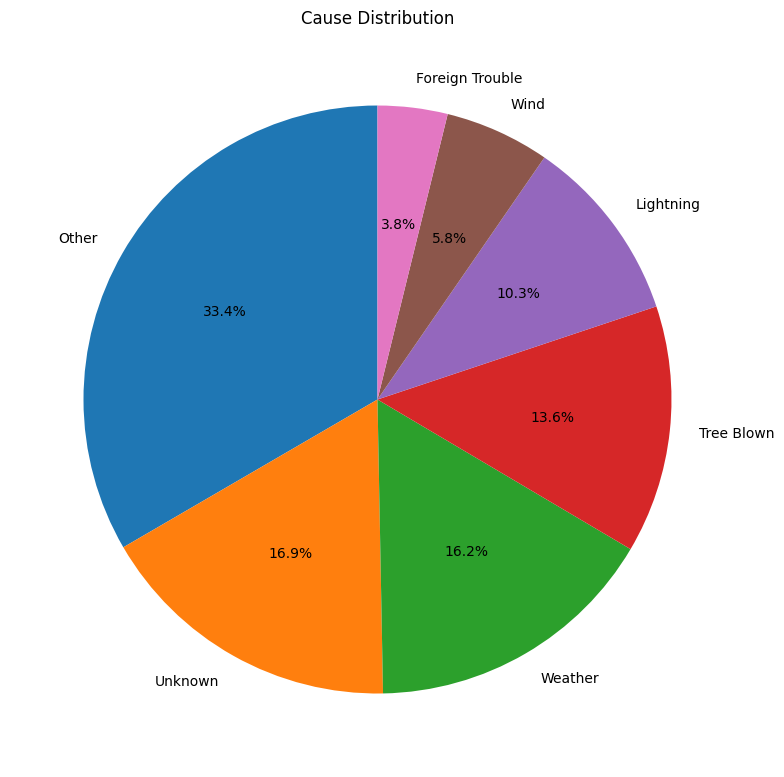

In [4]:
import matplotlib.pyplot as plt

cause_counts = df["Cause"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(cause_counts, labels=cause_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Cause Distribution")
plt.tight_layout()
plt.show()

由於 wheather 的比例比我想像中高、確認一下是否有異常事件在某個年度發生

看起來並沒有大型的天氣災害事件

In [5]:
# 各年度 Cause 分布
year_cause = df.groupby(["year", "Cause"]).size().unstack(fill_value=0)
year_cause_pct = year_cause.div(year_cause.sum(axis=1), axis=0).round(3) * 100
year_cause_pct

Cause,Foreign Trouble,Lightning,Other,Tree Blown,Unknown,Weather,Wind
year,,,,,,,
2012,2.8,9.9,49.0,10.3,13.7,12.2,2.1
2013,4.0,15.7,56.0,1.2,10.5,6.8,5.8
2014,1.8,14.2,28.4,9.7,23.0,17.6,5.3
2015,3.9,5.7,25.3,14.5,17.3,17.9,15.4
2016,6.8,2.1,43.3,12.6,19.3,15.0,1.0
2017,1.9,10.7,28.8,6.8,27.7,16.0,8.0
2018,4.6,9.6,36.5,13.2,14.6,16.2,5.2
2019,5.5,15.0,26.7,24.2,8.8,16.8,3.0
2020,4.4,8.2,22.1,23.6,15.2,21.6,5.1


## 2.4 Duration 直方圖

1. 線性直方圖

2. Log 尺度下直方圖

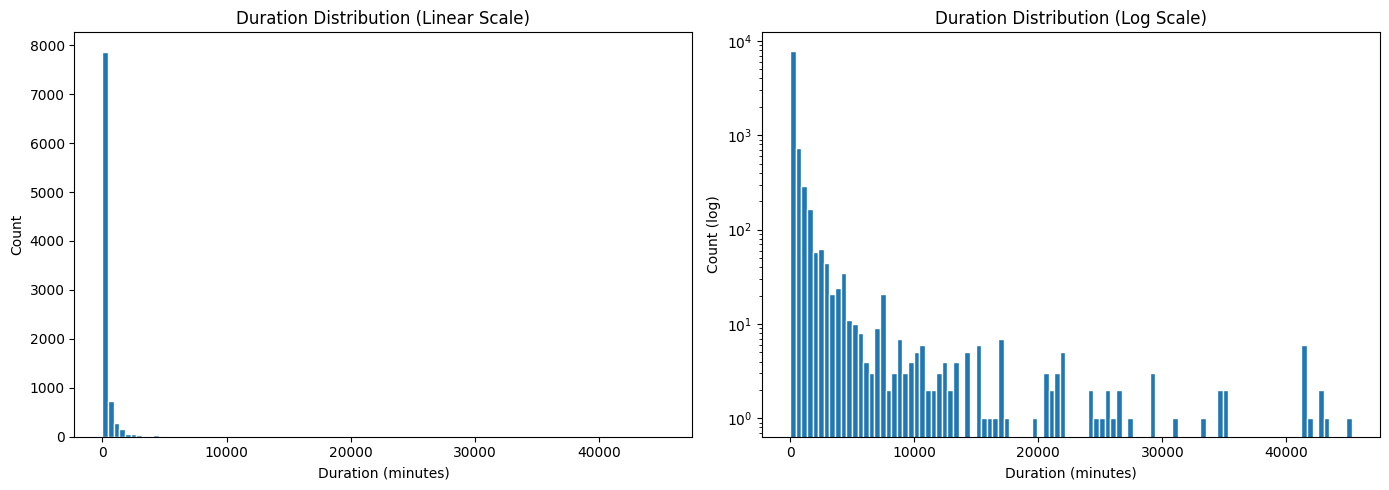

In [6]:
# 2.4 Duration 直方圖
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 線性尺度
axes[0].hist(df["Duration (minutes)"], bins=100, edgecolor="white")
axes[0].set_title("Duration Distribution (Linear Scale)")
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Count")

# Log 尺度
axes[1].hist(df["Duration (minutes)"], bins=100, edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("Duration Distribution (Log Scale)")
axes[1].set_xlabel("Duration (minutes)")
axes[1].set_ylabel("Count (log)")

plt.tight_layout()
plt.show()

# 3. CCDF 計算與繪製

* 目的 : 計算並繪製修復時間的經驗互補累積分布函數（CCDF），以 log-log 尺度呈現。若分布具有重尾特性，資料點在 log-log 圖上會呈現近似線性的行為。此圖將作為後續 log-normal 擬合比較的基準。

* 橫軸 : 修復時間（分鐘），以 log 尺度呈現，範圍從 1 分鐘到數萬分鐘，跨越多個數量級。

* 縱軸 : P(X > x) 互補累積機率，即修復時間超過 x 分鐘的機率，以 log 尺度呈現。數值越小代表該修復時間越罕見。

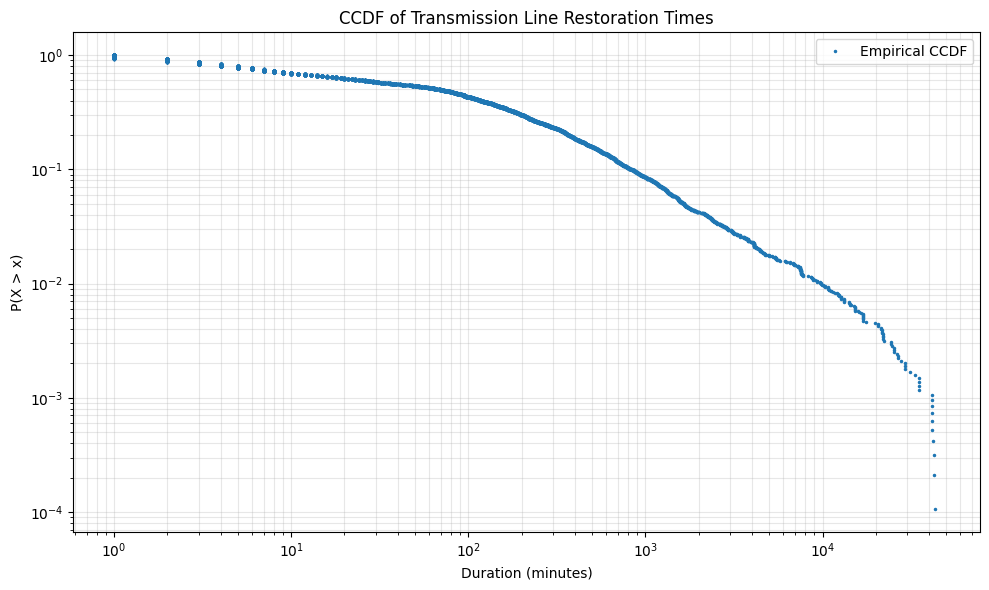

In [7]:
import numpy as np

# 依據修復時間做排序
duration_sorted = np.sort(df["Duration (minutes)"].values)

# 發生該修復時間的互補累積機率 (1-累積機率)
# 使用 arange 將 numpy 陣列做 [1,2...] 排列，也就是記數
ccdf = 1 - np.arange(1, len(duration_sorted) + 1) / len(duration_sorted)

plt.figure(figsize=(10, 6))
plt.loglog(duration_sorted, ccdf, marker=".", linestyle="none", markersize=3, label="Empirical CCDF")
plt.xlabel("Duration (minutes)")
# 修復時間超過 x 分鐘的機率
plt.ylabel("P(X > x)")
plt.title("CCDF of Transmission Line Restoration Times")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

# 4. 函式分布擬合

## 擬合狀況圖

Distribution      AIC   ΔAIC      BIC    KS D
  Log-normal 116368.0    0.0 116382.0 0.07334
  Gen. Gamma 116616.0  248.0 116637.0 0.06740
  Burr (XII) 116947.0  579.0 116969.0 0.09129
 Gen. Pareto 117511.0 1143.0 117525.0 0.11091
     Weibull 117622.0 1254.0 117636.0 0.10017
       Gamma 120499.0 4131.0 120513.0 0.13819


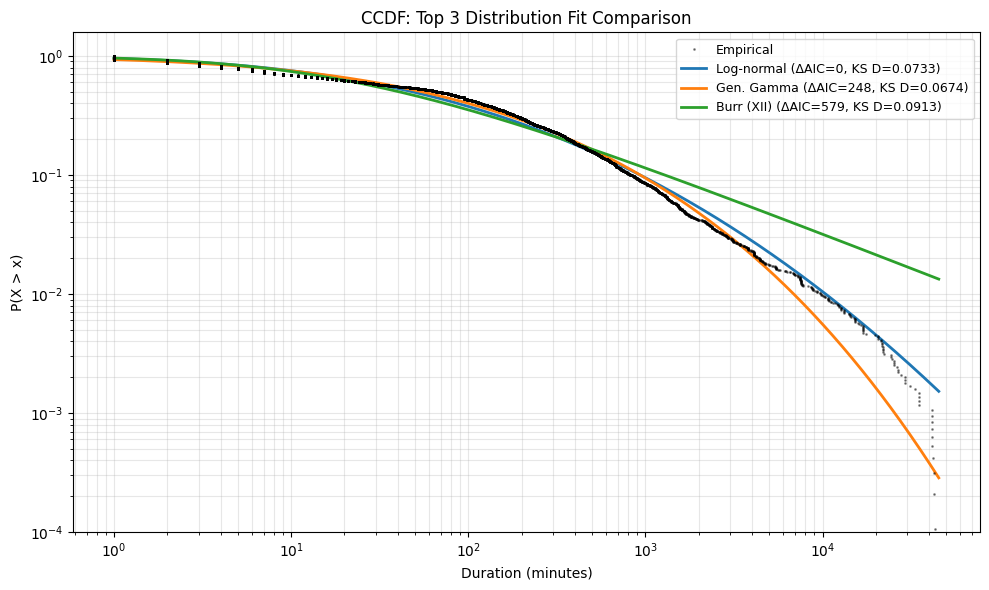

In [8]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

duration_sorted = np.sort(df["Duration (minutes)"].values).astype(float)
n = len(duration_sorted)
ccdf = 1 - np.arange(1, n + 1) / n

# ----------------------------------------------------------
# 5.1 Candidate Distribution Fitting (MLE) + AIC / BIC
# ----------------------------------------------------------
candidates = {
    "Log-normal":      stats.lognorm,
    "Weibull":         stats.weibull_min,
    "Gamma":           stats.gamma,
    "Burr (XII)":      stats.burr,
    "Gen. Pareto":     stats.genpareto,
    "Gen. Gamma":      stats.gengamma,
}

fit_results = []
fitted_params = {}

for name, dist in candidates.items():
    try:
        params = dist.fit(duration_sorted, floc=0)
        log_lik = dist.logpdf(duration_sorted, *params).sum()
        if not np.isfinite(log_lik):
            print(f"{name}: non-finite log-likelihood, skipped")
            continue
        k = len(params) - 1
        aic = 2 * k - 2 * log_lik
        bic = k * np.log(n) - 2 * log_lik
        ks_stat, _ = stats.kstest(duration_sorted, dist.cdf, args=params)
        fit_results.append({
            "Distribution": name,
            "AIC": round(aic, 0),
            "BIC": round(bic, 0),
            "KS D": round(ks_stat, 5),
            "params": params,
        })
        fitted_params[name] = (dist, params)
    except Exception as e:
        print(f"{name} fit failed: {e}")

results_df = pd.DataFrame(fit_results).sort_values("AIC").reset_index(drop=True)
results_df["ΔAIC"] = (results_df["AIC"] - results_df["AIC"].min()).round(0)
print(results_df[["Distribution", "AIC", "ΔAIC", "BIC", "KS D"]].to_string(index=False))

# ----------------------------------------------------------
# 5.2 CCDF Comparison — Top 3 only (full range, log-log)
# ----------------------------------------------------------
top3 = results_df.head(3)["Distribution"].tolist()
x_plot = np.logspace(np.log10(duration_sorted.min()), np.log10(duration_sorted.max()), 600)
colors = ["tab:blue", "tab:orange", "tab:green"]

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(duration_sorted, ccdf, "k.", markersize=2, alpha=0.4, label="Empirical", zorder=5)

for name, color in zip(top3, colors):
    dist, params = fitted_params[name]
    ccdf_th = 1 - dist.cdf(x_plot, *params)
    row = results_df[results_df["Distribution"] == name].iloc[0]
    ax.loglog(x_plot, ccdf_th, linewidth=2, color=color,
              label=f'{name} (ΔAIC={row["ΔAIC"]:.0f}, KS D={row["KS D"]:.4f})')

ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("P(X > x)")
ax.set_title("CCDF: Top 3 Distribution Fit Comparison")
ax.set_ylim(bottom=1e-4)
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

## 5. 說明與討論

部分論文使用 KS Test（Kolmogorov-Smirnov Test）來檢核對數常態分佈是否擬合，擬合結果難以達成(可上 git branch 中看前版本)，說明如下

* 原理

    KS test 計算實際 CCDF 和理論 CCDF 之間的最大差距（D 統計量）：
    >
    >    D = max|F_empirical(x) - F_theoretical(x)|
    >
    >    D 越小代表實際資料與理論分布越接近。

* p-value 計算

    1. 算出 D 統計量
    2. 將 D 標準化：D* = D × (√n + 0.12 + 0.11/√n)
    3. 將 D* 帶入 KS 分布的累積函數，得到 p-value

p-value 的直觀意思為：在 KS 分佈中觀測到這麼大或更大的 D 值的機率。

- p > 0.10 → 無法拒絕「資料符合該分布」的假設
- p ≤ 0.10 → 拒絕，資料不符合該分布

> 為何不適用於本題目 : 這個測試怎麼可能適合重尾，方法將最大誤差放大(跟 n 成正比)之後去觀察 KS 分佈超越該誤差的機率，但對於重尾情況來說，等於缺資料的地方不準確，準確的地方資料多，資料多還會去放大缺資料的誤差

# 6. 相對誤差檢核

* 原理

    >對每個資料點 x，計算實際 CCDF 與 log-normal 理論 CCDF 之間的相對誤差：
    >
    >   Relative Error = |F_empirical(x) - F_theoretical(x)| / F_empirical(x) => |預測值 - 實際值| / 實際值

* 相較於 KS test 只取最大差距，相對誤差法考慮每個點的誤差大小，能更全面反映整體的擬合品質，且不受樣本數影響。

* 誤差判斷標準 : 一般而言，相對誤差的判斷標準如下
    >
    > 誤差 < 5%：擬合非常好
    >
    > 誤差 5% ~ 10%：擬合良好，可接受
    >
    > 誤差 10% ~ 20%：擬合尚可，需注意偏離區間
    >
    > 誤差 > 20%：擬合較差，分布假設可能不適用

* 本資料的結果：

    - 中位數相對誤差 6.56%：整體擬合良好
    - 90th percentile 13.12%：90% 的資料點誤差在 13% 以內
    - 最大相對誤差 68.10%：尾部少數極端點偏離較大
    - 90th percentile = 0.1312：90% 的資料點，其相對誤差在 13.12% 以內
    - 95th percentile = 0.2341：95% 的資料點，其相對誤差在 23.41% 以內

因此 log-normal 在主體範圍內擬合良好，誤差主要集中在尾部極端值，為重尾分布的典型特徵。

# 7. 總結與策略

* 總結 : 

我認為主要問題出現在過於極端的修復時間上，完全同意極端事件的出現，但有部分修復時間數據超越 3 個月甚至達 2 年(這種修復時間，是會讓總統下台的那種，即便是以 921 全台灣電廠、輸電、配電全線受損的情況也才停 21 天)，就以常識而言怎麼可能會有這種情況，推測是由於該線路損壞後，採用其他線路供電，這條線路就慢慢修了，故將這些數據納入災害後復原分析並不具有意義，故建議設定修復時間上限值，以鐵塔倒塌修復時間 10 天作為上限值。

* 策略 : 
當給予模型機率事件時，超過 10 天的機率事件，維修時長以 10 天計算

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import os

# 5. Log-normal 有效範圍搜尋 — 固定截斷點 2×10⁴ min
# ── 資料載入 ──────────────────────────────────────────────────
DATA_DIR = "data"
df = pd.read_csv(os.path.join(DATA_DIR, "df_clean.csv"))
duration_sorted = np.sort(df["Duration (minutes)"].values).astype(float)
n_total = len(duration_sorted)

print(f"總樣本數：{n_total}")
print(f"範圍：{duration_sorted.min():.1f} ~ {duration_sorted.max():.1f} min")

# ── 參數設定 ──────────────────────────────────────────────────
T_CUT = 2e4  # 固定截斷點

# 全域擬合參數
params_global = stats.lognorm.fit(duration_sorted, floc=0)
print(f"全域擬合：μ = {np.log(params_global[2]):.4f}, σ = {params_global[0]:.4f}")

# ── 計算完整 ECDF ─────────────────────────────────────────────
ccdf_emp_all = 1 - np.arange(1, n_total + 1) / n_total

# ── 截斷點以內的誤差計算 ──────────────────────────────────────
mask_cut    = duration_sorted <= T_CUT
t_cut_data  = duration_sorted[mask_cut]
ccdf_cut    = ccdf_emp_all[mask_cut]
ccdf_th_cut = 1 - stats.lognorm.cdf(t_cut_data, *params_global)

valid       = ccdf_cut > 1e-6
rel_err_cut = np.abs(ccdf_cut[valid] - ccdf_th_cut[valid]) / ccdf_cut[valid]

n_cut  = mask_cut.sum()
pct_n  = n_cut / n_total * 100

print(f"\n截斷點：{T_CUT:.0f} min  ({T_CUT/60:.1f} hr  /  {T_CUT/(60*24):.1f} day)")
print(f"涵蓋樣本數：{n_cut} / {n_total}  ({pct_n:.1f}%)")
print(f"\n── 截斷點以內的相對誤差分布 ──")
for pct in [25, 50, 75, 90, 95, 99]:
    print(f"   P{pct:2d} = {np.percentile(rel_err_cut, pct)*100:.2f}%")
print(f"   Max = {rel_err_cut.max()*100:.2f}%")

# ── 視覺化 ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(11, 10))
fig.suptitle(f"Log-normal Valid Range — Fixed Cutoff at {T_CUT:.0f} min", fontsize=13)

x_plot  = np.logspace(np.log10(duration_sorted.min()), np.log10(duration_sorted.max()), 600)
ccdf_th = 1 - stats.lognorm.cdf(x_plot, *params_global)

# ── Plot 1: CCDF comparison ───────────────────────────────────
ax = axes[0]
ax.loglog(duration_sorted, ccdf_emp_all, "k.", markersize=2,
          alpha=0.35, label="Empirical CCDF", zorder=5)
ax.loglog(x_plot, ccdf_th, "b-", linewidth=1.5, label="Log-normal (global fit)")
ax.axvline(T_CUT, color="orange", linestyle=":", linewidth=1.5,
           label=f"Cutoff {T_CUT:.0f} min ({T_CUT/60:.0f} hr)")
ax.axvspan(T_CUT, duration_sorted.max(), alpha=0.07,
           color="gray", label="Beyond cutoff (extreme value region)")
ax.set_xlabel("Duration (minutes)")
ax.set_ylabel("P(X > x)")
ax.set_title("CCDF comparison: Log-normal fit vs empirical data")
ax.set_ylim(bottom=1e-4)
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)

# ── Plot 2: 相對誤差 vs duration（截斷點以內）────────────────
ax = axes[1]
ax.semilogx(t_cut_data[valid], rel_err_cut * 100,
            ".", color="steelblue", markersize=2, alpha=0.5, label="Relative error")
ax.axhline(np.median(rel_err_cut) * 100, color="red", linestyle="--",
           linewidth=1.2, label=f"Median = {np.median(rel_err_cut)*100:.2f}%")
ax.axhline(np.percentile(rel_err_cut, 95) * 100, color="orange", linestyle="--",
           linewidth=1.2, label=f"P95 = {np.percentile(rel_err_cut, 95)*100:.2f}%")
ax.set_xlabel("Duration (minutes, log scale)")
ax.set_ylabel("Relative error (%)")
ax.set_title(f"Relative error within cutoff (t ≤ {T_CUT:.0f} min)")
ax.legend(fontsize=9)
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()